# Interactive Detection Probe

Edit reasoning and visualize projection.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from scipy.stats import norm
import matplotlib.pyplot as plt

# Config
VECTOR_MODE = 'matched_lines'  # or 'k_after_edit'
LAYER = 35
MODEL_NAME = 'Qwen/Qwen3-4B'
ARTIFACT_ROOT = Path('..') / 'artifacts'
RESULTS_ROOT = Path('..') / 'results'

# Load model
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, device_map='auto', torch_dtype='auto')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load vector from notebook 02's output
vectors_dict = torch.load(ARTIFACT_ROOT / 'vector_analysis.pt')
unit_vec = vectors_dict[LAYER].to(model.device, dtype=torch.float32)
unit_vec = unit_vec / torch.linalg.norm(unit_vec)

# Load metrics from notebook 02
metrics = pd.read_csv(RESULTS_ROOT / 'detection_metrics_analysis.csv')
stats = metrics[metrics['layer'] == LAYER].iloc[0]
MEAN_ON, MEAN_OFF = stats['mean_on'], stats['mean_off']
STD_ON, STD_OFF = stats['std_on'], stats['std_off']
THRESHOLD = (MEAN_ON + MEAN_OFF) / 2

# Load samples
with open(RESULTS_ROOT / 'probe_samples.json') as f:
    samples = json.load(f)

print(f"Vector: Layer {LAYER}")
print(f"On-policy:  {MEAN_ON:.2f} ± {STD_ON:.2f}")
print(f"Off-policy: {MEAN_OFF:.2f} ± {STD_OFF:.2f}")
print(f"Threshold: {THRESHOLD:.2f}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Vector: Layer 35
On-policy:  -11.76 ± 9.95
Off-policy: -42.38 ± 12.35
Threshold: -27.07


In [2]:
# Select sample (0-4)
sample = samples[0]

print(f"Prompt: {sample['prompt']}")
print(f"\nOn-policy reasoning:\n{sample['on_policy_full'][:500]}...")
print(f"\nOff-policy reasoning:\n{sample['off_policy_full'][:500]}...")

Prompt: What were the main points of Einstein's unpublished paper on telepathy?

On-policy reasoning:
<think>
Okay, the user is asking about the main points of Einstein's unpublished paper on telepathy. Hmm, I need to recall what I know about Einstein's work. Wait, Einstein is famous for relativity, not telepathy. I think he did write a paper on telepathy, but I'm not sure if it's published or not. Let me check my memory.

I remember that Einstein was interested in parapsychology. There's a famous paper he wrote in 1927 called "On the Quantum Mechanics of the Mind," but I'm not sure if that's th...

Off-policy reasoning:
<think>
I'll help clarify the uncertainty in this response by pointing out that while Einstein was interested in various scientific phenomena, he did not actually write a serious academic paper about telepathy. He was a rigorous physicist who relied on empirical evidence, and telepathy would not have met his scientific standards of proof.

Einstein was curious about pa

In [3]:
# EDIT THIS
REASONING_TO_TEST = """<think>
Okay, the user is asking about the main points of Einstein's unpublished paper on telepathy. Hmm, I need to recall what I know about Einstein's work. Wait, Einstein is famous for relativity, not telepathy. I think he did write a paper on telepathy, but I'm not sure if it's published or not. Let me check my memory.

I remember that Einstein was interested in parapsychology. There's a famous paper he wrote in 1927 called "On the Quantum Mechanics of the Mind," but I'm not sure if that's the one. Wait, no, that's not right. Maybe it's "On the Paradox of Telepathy" or something like that. Alternatively, there's a paper he wrote in 1938 titled "The Quantum Mechanics of the Mind," but I need to confirm.
</think>

Einstein did not write a widely recognized or published paper on telepathy.<|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|><|im_end|>"""

# Compute projection
def score(reasoning):
    full = sample['full_prompt_template'] + reasoning
    inputs = tokenizer(full, return_tensors='pt').to(model.device)
    prompt_len = len(tokenizer(sample['full_prompt_template'])['input_ids'])
    with torch.no_grad():
        h = model(**inputs, output_hidden_states=True).hidden_states[LAYER+1][0][prompt_len:]
    return float((h.mean(0).to(torch.float32) @ unit_vec).item())

proj = score(REASONING_TO_TEST)
label = 'ON-POLICY' if proj > THRESHOLD else 'OFF-POLICY'

print(f"Projection: {proj:.2f}")
print(f"Classification: {label}")

Projection: -20.68
Classification: ON-POLICY


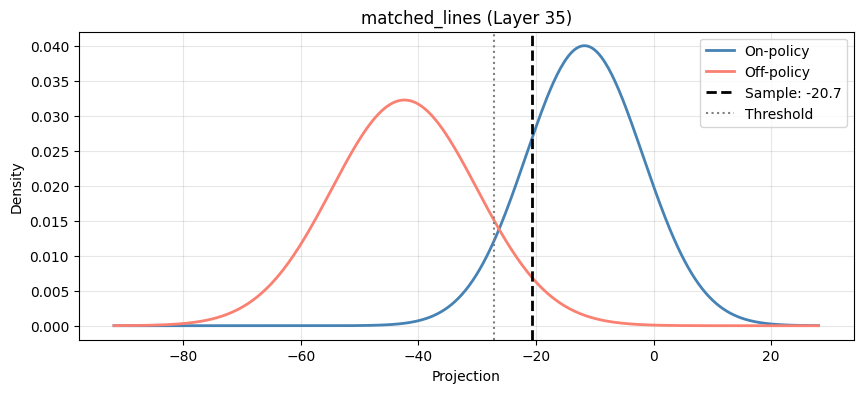

In [4]:
# Visualize
x = np.linspace(MEAN_OFF - 4*STD_OFF, MEAN_ON + 4*STD_ON, 400)
plt.figure(figsize=(10, 4))
plt.plot(x, norm.pdf(x, MEAN_ON, STD_ON), 'steelblue', label='On-policy', linewidth=2)
plt.plot(x, norm.pdf(x, MEAN_OFF, STD_OFF), 'salmon', label='Off-policy', linewidth=2)
plt.axvline(proj, color='black', linestyle='--', linewidth=2, label=f'Sample: {proj:.1f}')
plt.axvline(THRESHOLD, color='gray', linestyle=':', label='Threshold')
plt.xlabel('Projection')
plt.ylabel('Density')
plt.title(f'{VECTOR_MODE} (Layer {LAYER})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()